In [1]:
from pathlib import Path
import json
import random

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim

import numpy as np
from tqdm import tqdm

In [2]:
%reload_ext tensorboard
%tensorboard --logdir ../runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/home/chris/miniconda3/envs/ramenv/bin/tensorboard", line 6, in <module>
    from tensorboard.main import run_main
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [3]:
rows, cols = 64, 64

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no esta disponible. Este notebook requiere entrenamiento en GPU.")

device = torch.device("cuda")
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.benchmark = True
print(device)

DATA_DIR = Path("../data/dataset2-master/dataset2-master/images")
TENSORBOARD_LOG_DIR = Path("../runs/vgg11_half")
TENSORBOARD_LOG_DIR.mkdir(parents=True, exist_ok=True)

TENSORBOARD_BN_LOG_DIR = Path("../runs/vgg11_half_bn")
TENSORBOARD_BN_LOG_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("../results")
HISTORY_DIR = RESULTS_DIR / "histories"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

train_dir = DATA_DIR / "TRAIN"
test_dir = DATA_DIR / "TEST"

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((rows, cols)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

num_classes = len(train_dataset.classes)
print(f"Clases detectadas ({num_classes}): {train_dataset.classes}")

Clases detectadas (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [5]:
BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from models.vgg import VGG11Half, VGG11HalfBN

In [7]:
def train(model, device, train_loader, optimizer, criterion, epoch, writer=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Training epoch {epoch}")
    for batch_idx, (data, target) in progress_bar:
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        batch_acc = correct / total
        global_step = (epoch - 1) * len(train_loader) + batch_idx

        progress_bar.set_postfix(loss=batch_loss, acc=batch_acc)
        if writer is not None:
            writer.add_scalar("Loss/train_batch", batch_loss, global_step)
            writer.add_scalar("Accuracy/train_batch", batch_acc, global_step)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    if writer is not None:
        writer.add_scalar("Loss/train_epoch", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train_epoch", epoch_acc, epoch)
    return epoch_loss, epoch_acc


def evaluate(model, device, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            outputs = model(data)
            loss = criterion(outputs, target)

            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def new_history(model_name):
    return {
        "model": model_name,
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }


def append_history(history, epoch, train_loss, train_acc, test_loss, test_acc):
    history["epoch"].append(int(epoch))
    history["train_loss"].append(float(train_loss))
    history["test_loss"].append(float(test_loss))
    history["train_acc"].append(float(train_acc))
    history["test_acc"].append(float(test_acc))


def save_history(history, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(history, indent=2), encoding="utf-8")


def load_history(path):
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}. Ejecuta primero las celdas de entrenamiento para generar el history.")
    return json.loads(path.read_text(encoding="utf-8"))


def history_metric(history, key):
    return history["epoch"], history[key]

In [8]:
model_original = VGG11Half(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_original.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
writer = SummaryWriter(log_dir=str(TENSORBOARD_LOG_DIR))

sample_images, _ = next(iter(train_loader))
sample_images = sample_images.to(device, non_blocking=True)
with torch.no_grad():
    sample_outputs = model_original(sample_images)
print(f"Forward pass VGG11Half: {sample_outputs.shape}")

Forward pass VGG11Half: torch.Size([32, 4])


In [9]:
EPOCHS = 10
history_original = new_history("VGG11Half")

try:
    writer.add_graph(model_original, sample_images)
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_original, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_original, device, test_loader, criterion)
    append_history(history_original, epoch, train_loss, train_acc, test_loss, test_acc)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
save_history(history_original, HISTORY_DIR / "vgg11_half_history.json")
torch.save(model_original.state_dict(), MODELS_DIR / "vgg11_half.pth")

Training epoch 1: 100%|██████████| 312/312 [00:15<00:00, 20.79it/s, acc=0.248, loss=1.38]


Epoch 1/10 - train_loss: 1.3873 - train_acc: 0.2482 - test_loss: 1.3865 - test_acc: 0.2505


Training epoch 2: 100%|██████████| 312/312 [00:13<00:00, 22.31it/s, acc=0.25, loss=1.41] 


Epoch 2/10 - train_loss: 1.3868 - train_acc: 0.2499 - test_loss: 1.3867 - test_acc: 0.2493


Training epoch 3: 100%|██████████| 312/312 [00:14<00:00, 21.00it/s, acc=0.252, loss=1.4] 


...

Epoch 8/10 - train_loss: 1.3872 - train_acc: 0.2477 - test_loss: 1.3868 - test_acc: 0.2509


Training epoch 9: 100%|██████████| 312/312 [00:13<00:00, 23.08it/s, acc=0.243, loss=1.37]


Epoch 9/10 - train_loss: 1.3871 - train_acc: 0.2428 - test_loss: 1.3866 - test_acc: 0.2493


Training epoch 10: 100%|██████████| 312/312 [00:13<00:00, 23.28it/s, acc=0.252, loss=1.38]


Epoch 10/10 - train_loss: 1.3870 - train_acc: 0.2519 - test_loss: 1.3865 - test_acc: 0.2493


In [10]:
model_bn = VGG11HalfBN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
writer = SummaryWriter(log_dir=str(TENSORBOARD_BN_LOG_DIR))

sample_images, _ = next(iter(train_loader))
sample_images = sample_images.to(device, non_blocking=True)
with torch.no_grad():
    sample_outputs = model_bn(sample_images)
print(f"Forward pass VGG11HalfBN: {sample_outputs.shape}")

Forward pass VGG11HalfBN: torch.Size([32, 4])


In [11]:
EPOCHS = 10
history_bn = new_history("VGG11HalfBN")

try:
    writer.add_graph(model_bn, sample_images)
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_bn, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_bn, device, test_loader, criterion)
    append_history(history_bn, epoch, train_loss, train_acc, test_loss, test_acc)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
save_history(history_bn, HISTORY_DIR / "vgg11_half_bn_history.json")
torch.save(model_bn.state_dict(), MODELS_DIR / "vgg11_half_bn.pth")

Training epoch 1: 100%|██████████| 312/312 [00:13<00:00, 23.98it/s, acc=0.339, loss=0.951]


Epoch 1/10 - train_loss: 1.2908 - train_acc: 0.3389 - test_loss: 1.0372 - test_acc: 0.4616


Training epoch 2: 100%|██████████| 312/312 [00:13<00:00, 23.83it/s, acc=0.608, loss=1.18] 


Epoch 2/10 - train_loss: 0.7776 - train_acc: 0.6081 - test_loss: 1.3724 - test_acc: 0.6289


Training epoch 3: 100%|██████████| 312/312 [00:13<00:00, 23.44it/s, acc=0.728, loss=0.256]


...

Epoch 8/10 - train_loss: 0.1340 - train_acc: 0.9548 - test_loss: 1.4365 - test_acc: 0.6671


Training epoch 9: 100%|██████████| 312/312 [00:13<00:00, 23.71it/s, acc=0.959, loss=1.03]   


Epoch 9/10 - train_loss: 0.1183 - train_acc: 0.9586 - test_loss: 1.1541 - test_acc: 0.7857


Training epoch 10: 100%|██████████| 312/312 [00:13<00:00, 23.91it/s, acc=0.965, loss=0.0128] 


Epoch 10/10 - train_loss: 0.0944 - train_acc: 0.9649 - test_loss: 4.5836 - test_acc: 0.6385


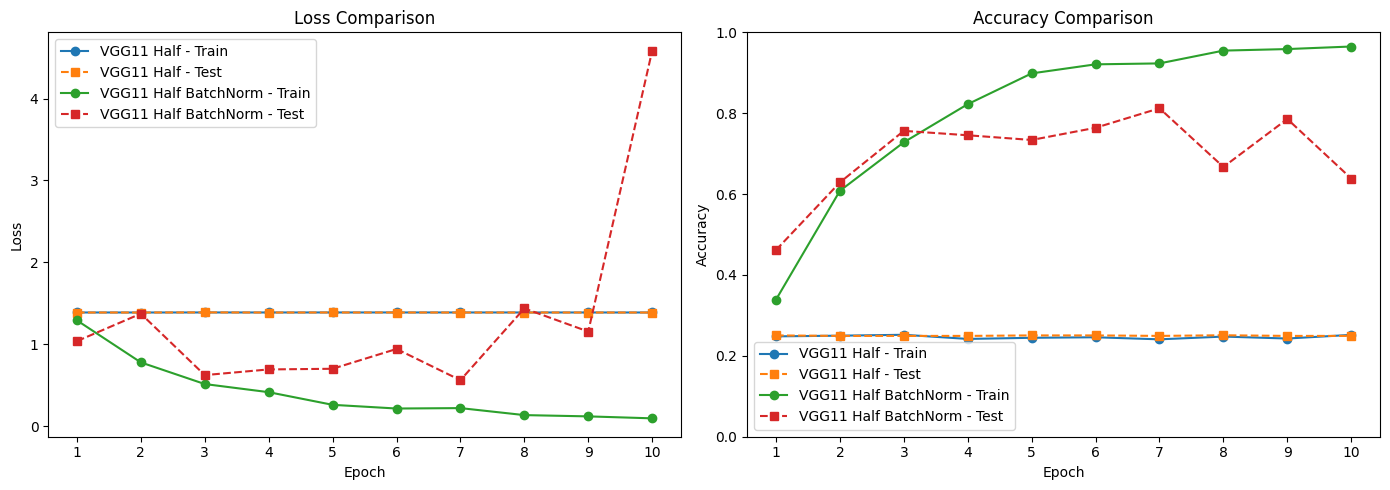

In [12]:
import matplotlib.pyplot as plt

histories = [
    (load_history(HISTORY_DIR / "vgg11_half_history.json"), "VGG11 Half"),
    (load_history(HISTORY_DIR / "vgg11_half_bn_history.json"), "VGG11 Half BatchNorm"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for history, label in histories:
    epochs = history["epoch"]
    axes[0].plot(epochs, history["train_loss"], linestyle="-", marker="o", label=f"{label} - Train")
    axes[0].plot(epochs, history["test_loss"], linestyle="--", marker="s", label=f"{label} - Test")
    axes[1].plot(epochs, history["train_acc"], linestyle="-", marker="o", label=f"{label} - Train")
    axes[1].plot(epochs, history["test_acc"], linestyle="--", marker="s", label=f"{label} - Test")

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(histories[0][0]["epoch"])
axes[0].legend()

axes[1].set_title("Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(histories[0][0]["epoch"])
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()